<!-- colab-badge -->
[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bmnogueira-ufms/IA-2026-02/blob/main/Aulas%20Pr%C3%A1ticas/aula05-otimizacao/aula05-gabarito.ipynb)

# Aula 05 - Otimização de Redes Neurais - Gabarito

**Inteligência Artificial - Graduação**
Prof. Bruno Nogueira - FACOM/UFMS - 2026/2

---

## Do que trata esta aula

A aula 04 terminou com uma tabela incômoda: redes de 2, 5, 10, 30 e 100 unidades
escondidas, acurácia de treino subindo até 100% e acurácia de teste empacando em 98%.
E com uma pergunta: **qual arquitetura escolher?**

Repare no que fizemos lá para responder: olhamos a coluna do teste e escolhemos a
melhor. Era o caminho mais natural do mundo, e estava errado. A partir do momento em
que uma decisão é tomada olhando o conjunto de teste, ele deixa de medir o que
prometia medir - e a estimativa de desempenho vira propaganda.

Esta aula é sobre **método**: como dividir os dados, como escolher hiperparâmetros sem
se enganar, como diagnosticar se o modelo está simples ou complexo demais, e o que
fazer em cada caso. Nada aqui é específico de redes neurais - vale para qualquer
algoritmo da disciplina. Mas é em redes que a coisa dói mais, porque há muito o que
escolher: camadas, unidades, $\alpha$, épocas, regularização.

### Roteiro

| # | Tema | Conceito da teoria |
|---|------|--------------------|
| 1 | Treino, validação e teste | por que são **três** |
| 2 | Mesma distribuição | o gato da internet × o gato do celular |
| 3 | Validação cruzada | k-fold, repetida, aninhada |
| 4 | Bias e variância | o diagnóstico pelos dois erros |
| 5 | Regularização | L2, $\lambda$, L1 |
| 6 | Regularização em redes | *weight decay* e a volta ao linear |
| 7 | Dropout | desligar unidades de propósito |
| 8 | Data augmentation | inventar dados honestos |
| 9 | Early stopping | parar na hora certa |

> **Gabarito.** Este é o mesmo notebook da aula, com as lacunas preenchidas e todas as células executadas. As respostas das perguntas de interpretação estão em células de markdown marcadas com **🎯 Conclusão**.

---
## 0. Preparando o ambiente

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.figsize": (7, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

CORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
MAPA_REGIOES = ListedColormap(["#D6DEEC", "#F7DFCE"])


# Três funções da aula 04, repetidas aqui para o notebook ser autocontido.
def sigmoide(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, dtype=float)))


def com_bias(X):
    X = np.asarray(X, dtype=float)
    return np.c_[np.ones(len(X)), X]


def plota_regioes(modelo, X, y, ax, titulo=""):
    """Pinta as regiões de decisão de um modelo sobre uma grade 2D."""
    passo = 0.02
    x1 = np.arange(X[:, 0].min() - 0.4, X[:, 0].max() + 0.4, passo)
    x2 = np.arange(X[:, 1].min() - 0.4, X[:, 1].max() + 0.4, passo)
    G1, G2 = np.meshgrid(x1, x2)
    Z = modelo.predict(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
    ax.contourf(G1, G2, Z, alpha=0.6, cmap=MAPA_REGIOES)
    for classe, marcador in [(0, "o"), (1, "s")]:
        m = y == classe
        ax.scatter(X[m, 0], X[m, 1], s=22, marker=marcador, color=CORES[classe],
                   edgecolor="white", linewidth=0.4, label=f"classe {classe}")
    ax.set_title(titulo, fontsize=10)


print(f"NumPy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print("\nAmbiente pronto.")

NumPy        2.4.4
pandas       3.0.2
scikit-learn 1.8.0

Ambiente pronto.


---
## 1. Por que são **três** conjuntos

A aula 01 já separava treino e teste. Falta o do meio.

- **Treino**: onde a hipótese é induzida. Os $\theta$ saem daqui.
- **Validação**: onde as **configurações** são comparadas. Quantas unidades, que
  $\lambda$, que $\alpha$ - tudo isso se decide aqui.
- **Teste**: onde a configuração escolhida é medida **uma vez**, no fim. Não se
  escolhe nada olhando o teste.

A lógica é a mesma nos dois cortes. Medir o erro nos dados que ajustaram os $\theta$ é
otimista - foi por isso que separamos treino de teste na aula 01. Medir o erro nos
dados que escolheram a **arquitetura** é otimista pelo mesmo motivo, só que um nível
acima. Vamos ver o tamanho desse otimismo.

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

digitos = load_digits()
X, y = digitos.data, digitos.target

# 60% treino / 20% validação / 20% teste - uma das proporções do slide 6.
X_tr, X_resto, y_tr, y_resto = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y)
X_va, X_te, y_va, y_te = train_test_split(
    X_resto, y_resto, test_size=0.5, random_state=RANDOM_STATE, stratify=y_resto)

print(f"treino:    {len(y_tr):5}  ({len(y_tr) / len(y):.0%})")
print(f"validação: {len(y_va):5}  ({len(y_va) / len(y):.0%})")
print(f"teste:     {len(y_te):5}  ({len(y_te) / len(y):.0%})")
print("\n`stratify=y` mantém a proporção das 10 classes nos três conjuntos.")

treino:     1078  (60%)
validação:   359  (20%)
teste:       360  (20%)

`stratify=y` mantém a proporção das 10 classes nos três conjuntos.


In [3]:
ARQUITETURAS = [(2,), (5,), (10,), (20,), (30,), (60,), (100,)]

linhas = []
for camada in ARQUITETURAS:
    modelo = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=camada, activation="logistic",
                      max_iter=600, random_state=RANDOM_STATE),
    ).fit(X_tr, y_tr)
    linhas.append({
        "unidades": camada[0],
        "acurácia treino": modelo.score(X_tr, y_tr),
        "acurácia validação": modelo.score(X_va, y_va),
        "acurácia teste": modelo.score(X_te, y_te),
    })

tabela = pd.DataFrame(linhas)
print(tabela.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

escolhida = tabela.loc[tabela["acurácia validação"].idxmax()]
print(f"\nMelhor na VALIDAÇÃO: {int(escolhida['unidades'])} unidades, "
      f"{escolhida['acurácia validação']:.2%}")
print(f"Desempenho dessa mesma rede no TESTE:            "
      f"{escolhida['acurácia teste']:.2%}")
print(f"Otimismo da estimativa de validação: "
      f"{(escolhida['acurácia validação'] - escolhida['acurácia teste']) * 100:+.2f} pontos")

 unidades  acurácia treino  acurácia validação  acurácia teste
        2           0.4156              0.4206          0.4083
        5           0.9629              0.8607          0.8722
       10           0.9944              0.9304          0.9194
       20           1.0000              0.9749          0.9389
       30           1.0000              0.9777          0.9667
       60           1.0000              0.9694          0.9611
      100           1.0000              0.9749          0.9667

Melhor na VALIDAÇÃO: 30 unidades, 97.77%
Desempenho dessa mesma rede no TESTE:            96.67%
Otimismo da estimativa de validação: +1.10 pontos


🔎 **PARE E PENSE**: a diferença acima é pequena, mas ela tem **sinal**. E não é
coincidência: escolhemos o **máximo** de sete medidas ruidosas, e o máximo de várias
medidas ruidosas é quase sempre otimista - parte do valor é mérito, parte é sorte
daquele sorteio. Com 50 configurações em vez de 7, o otimismo cresce. É por isso que
o número que se reporta no fim é o do **teste**, medido na configuração já escolhida.

E as proporções? Os slides listam 70/30, 60/20/20 e lembram que, com bases enormes,
elas deixam de fazer sentido: 20% de um milhão de exemplos são 200 mil exemplos de
validação, muito mais do que o necessário para comparar configurações.

In [4]:
print(f"{'tamanho da base':>18} {'20% para teste':>16} {'1% para teste':>16}")
for m in [200, 2_000, 20_000, 1_000_000, 10_000_000]:
    print(f"{m:>18,} {int(0.20 * m):>16,} {int(0.01 * m):>16,}".replace(",", "."))
print("\nCom 10 milhões de exemplos, 1% ainda dá 100 mil casos de teste - de sobra.")
print("Com 200, tirar 20% já dói. Base pequena pede validação cruzada (seção 3).")

   tamanho da base   20% para teste    1% para teste
               200               40                2
             2.000              400               20
            20.000            4.000              200
         1.000.000          200.000           10.000
        10.000.000        2.000.000          100.000

Com 10 milhões de exemplos, 1% ainda dá 100 mil casos de teste - de sobra.
Com 200, tirar 20% já dói. Base pequena pede validação cruzada (seção 3).


---
## 2. Todos os dados têm de vir da **mesma distribuição**

O slide 7 conta o caso das fotos de gatos: treinar com imagens catadas na internet e
testar com fotos tiradas de celular. Os dois conjuntos são "fotos de gatos", mas não
são a mesma amostra - resolução, enquadramento e iluminação mudam, e o que o modelo
aprendeu pode não valer lá.

Dá para simular isso com os dígitos de um jeito cruel: e se as imagens de teste
estivessem deslocadas **um pixel** para o lado? Para um humano, nada muda.

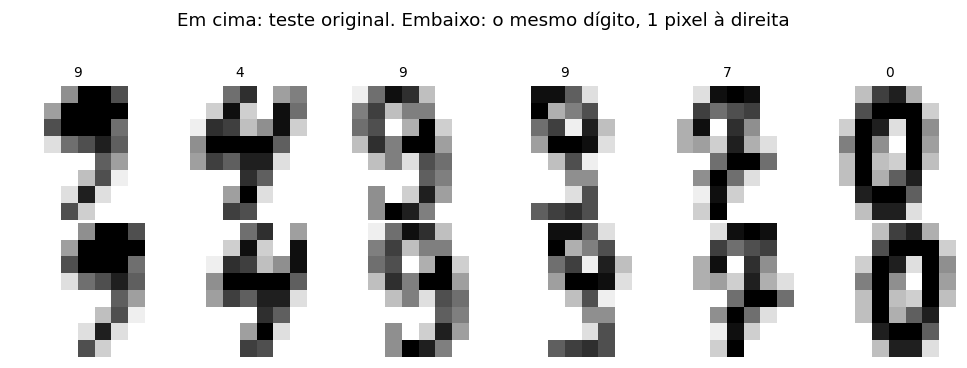

Acurácia no teste original:            96.67%
Acurácia com deslocamento (0, 1):     37.50%
Acurácia com deslocamento (1, 0):     38.33%
Acurácia com deslocamento (1, 1):     13.61%


In [5]:
from scipy.ndimage import shift


def desloca(imagens, dy, dx):
    """Desloca cada imagem 8x8 em (dy, dx) pixels, preenchendo com fundo."""
    return np.array([
        shift(img.reshape(8, 8), (dy, dx), order=0, mode="constant", cval=0).ravel()
        for img in imagens
    ])


rede = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(30,), activation="logistic",
                  max_iter=600, random_state=RANDOM_STATE),
).fit(X_tr, y_tr)

fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
for j in range(6):
    axes[0, j].imshow(X_te[j].reshape(8, 8), cmap="gray_r")
    axes[0, j].set_title(f"{y_te[j]}", fontsize=9)
    axes[1, j].imshow(desloca(X_te[j:j + 1], 0, 1)[0].reshape(8, 8), cmap="gray_r")
    for i in range(2):
        axes[i, j].axis("off")
axes[0, 0].set_ylabel("original")
fig.suptitle("Em cima: teste original. Embaixo: o mesmo dígito, 1 pixel à direita", y=1.03)
plt.tight_layout()
plt.show()

print(f"Acurácia no teste original:            {rede.score(X_te, y_te):.2%}")
for dy, dx in [(0, 1), (1, 0), (1, 1)]:
    print(f"Acurácia com deslocamento ({dy}, {dx}):     "
          f"{rede.score(desloca(X_te, dy, dx), y_te):.2%}")

🎯 De 96% para 37% com um pixel. A rede não aprendeu "a forma do algarismo": aprendeu
**quais pixels acendem**, que é o que os dados ofereciam. Nada aqui é bug - o
treinamento foi correto, a validação foi correta, e mesmo assim o modelo é inútil na
situação nova. Guarde este exemplo: ele volta na seção 8, e o conserto é surpreendente.

---
## 3. Validação cruzada

Dividir uma vez tem um problema: o resultado depende do sorteio. Com 359 exemplos de
validação, trocar a semente muda a acurácia em alguns décimos - e a gente acaba
escolhendo configuração no ruído.

A **validação cruzada k-fold** resolve fazendo todo mundo ser validação uma vez: divide
a base em $k$ partes, treina $k$ vezes usando $k-1$ partes e validando na que sobrou.

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

modelo_base = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(30,), activation="logistic",
                  max_iter=400, random_state=RANDOM_STATE),
)

t0 = time.time()
notas = cross_val_score(
    modelo_base, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))
print(f"5-fold estratificado: {np.round(notas, 4)}")
print(f"média {notas.mean():.4f}   desvio {notas.std():.4f}   "
      f"({time.time() - t0:.1f} s, 5 treinamentos)")
print(f"\nAmplitude entre o pior e o melhor fold: "
      f"{(notas.max() - notas.min()) * 100:.1f} pontos percentuais.")
print("Se a sua decisão depende de meio ponto, uma divisão única não serve.")

5-fold estratificado: [0.9611 0.9722 0.9749 0.9889 0.9833]
média 0.9761   desvio 0.0095   (5.3 s, 5 treinamentos)

Amplitude entre o pior e o melhor fold: 2.8 pontos percentuais.
Se a sua decisão depende de meio ponto, uma divisão única não serve.


### 🔨 IMPLEMENTE 1 - validação cruzada repetida

A **validação cruzada repetida** do slide 12 embaralha a base e refaz o k-fold inteiro
$r$ vezes. Cada repetição sorteia folds diferentes, e a média sobre $k \times r$
treinamentos é bem mais estável.

In [7]:
from sklearn.base import clone

def cv_repetida(modelo, X, y, k=5, repeticoes=3, semente=RANDOM_STATE):
    """Validação cruzada repetida, na mão.

    Parâmetros
    ----------
    modelo : estimador do scikit-learn (NÃO treinado)
    k      : número de folds
    repeticoes : quantas vezes repetir o k-fold inteiro, reembaralhando

    Devolve
    -------
    np.ndarray com k * repeticoes acurácias
    """
    notas = []
    for r in range(repeticoes):
        # Semente diferente a cada repetição = folds diferentes.
        particionador = StratifiedKFold(k, shuffle=True, random_state=semente + r)
        for indices_treino, indices_val in particionador.split(X, y):
            copia = clone(modelo)
            copia.fit(X[indices_treino], y[indices_treino])
            notas.append(copia.score(X[indices_val], y[indices_val]))
    return np.array(notas)

In [8]:
# Conferência da IMPLEMENTE 1: com 1 repetição, tem que bater com o cross_val_score.
uma_rep = cv_repetida(modelo_base, X, y, k=5, repeticoes=1)
assert uma_rep.shape == (5,), f"5 folds x 1 repetição = 5 notas, vieram {uma_rep.shape}"
assert np.allclose(uma_rep, notas), \
    f"com uma repetição deveria dar o mesmo que o cross_val_score:\n{uma_rep}\n{notas}"
print("OK - a sua validação cruzada repetida bate com o scikit-learn.")

t0 = time.time()
repetida = cv_repetida(modelo_base, X, y, k=5, repeticoes=3)
print(f"\n5-fold x 3 repetições: {len(repetida)} treinamentos em {time.time() - t0:.1f} s")
print(f"média {repetida.mean():.4f}   desvio {repetida.std():.4f}")
print(f"(o 5-fold simples deu média {notas.mean():.4f}, desvio {notas.std():.4f})")

OK - a sua validação cruzada repetida bate com o scikit-learn.



5-fold x 3 repetições: 15 treinamentos em 16.5 s
média 0.9748   desvio 0.0098
(o 5-fold simples deu média 0.9761, desvio 0.0095)


### Validação cruzada aninhada

Falta um detalhe incômodo: se usarmos a validação cruzada para **escolher** a
configuração e reportarmos a nota dela, voltamos ao problema da seção 1 - a estimativa
foi contaminada pela escolha.

A **validação cruzada aninhada** (slides 9 e 10) resolve com dois laços. O laço de
fora separa um fold de teste; o de dentro faz validação cruzada **só nos dados
restantes** para escolher a configuração; a configuração escolhida é medida no fold
de teste, que nunca participou da escolha.

In [9]:
from sklearn.model_selection import GridSearchCV

grade = {"mlpclassifier__hidden_layer_sizes": [(5,), (30,), (100,)]}
modelo_rapido = make_pipeline(
    StandardScaler(),
    MLPClassifier(activation="logistic", max_iter=300, random_state=RANDOM_STATE),
)

# Laço interno: escolhe a arquitetura.
busca = GridSearchCV(modelo_rapido, grade,
                     cv=StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE),
                     n_jobs=-1)

# Laço externo: mede a configuração escolhida em dados que o laço interno não viu.
t0 = time.time()
aninhada = cross_val_score(
    busca, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
tempo_aninhada = time.time() - t0

# Para comparar: a nota que o GridSearchCV reporta sobre a base inteira.
t0 = time.time()
so_busca = GridSearchCV(modelo_rapido, grade,
                        cv=StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE),
                        n_jobs=-1).fit(X, y)
tempo_busca = time.time() - t0

n_config, k_ext, k_int = len(grade["mlpclassifier__hidden_layer_sizes"]), 5, 4
print(f"Aninhada: {aninhada.round(4)}")
print(f"  média {aninhada.mean():.4f}   ({n_config} x {k_ext} x {k_int} = "
      f"{n_config * k_ext * k_int} treinamentos, {tempo_aninhada:.0f} s)")
print(f"\nSó a busca: melhor = {so_busca.best_params_}")
print(f"  nota reportada {so_busca.best_score_:.4f}   "
      f"({n_config * k_int} treinamentos, {tempo_busca:.0f} s)")
print("\nA aninhada custa uma ordem de grandeza mais e é a estimativa honesta;")
print("a busca sozinha escolhe a configuração, mas não serve para reportar desempenho.")

Aninhada: [0.9806 0.9778 0.9805 0.9805 0.9805]
  média 0.9800   (3 x 5 x 4 = 60 treinamentos, 53 s)

Só a busca: melhor = {'mlpclassifier__hidden_layer_sizes': (100,)}
  nota reportada 0.9766   (12 treinamentos, 19 s)

A aninhada custa uma ordem de grandeza mais e é a estimativa honesta;
a busca sozinha escolhe a configuração, mas não serve para reportar desempenho.


🎯 Um resumo prático dos slides 13 e 14:

| esquema | custo | quando usar |
|---|---|---|
| holdout (1 divisão) | 1 treinamento | base muito grande (ImageNet) |
| k-fold | $k$ | algoritmo sem hiperparâmetros a calibrar |
| repetida | $n \cdot k \cdot r$ | base média, ajuste de hiperparâmetros |
| aninhada | $n \cdot k \cdot (k-1)$ | base pequena, estimativa não enviesada |

E os dois processos são **paralelizáveis** - foi o que o `n_jobs=-1` fez acima.

---
## 4. Bias e variância: lendo os dois erros

Sabendo medir direito, vem a pergunta seguinte: o modelo está errando **por quê**?

- **Alto bias** (*underfitting*): a hipótese é simples demais para o problema. Erra no
  treino e erra na validação, quase igual. A rede de 2 unidades da aula 04 (42% nos
  dois) é o retrato disso.
- **Alta variância** (*overfitting*): a hipótese é flexível demais e decorou o
  treino. Erra pouco no treino e muito na validação.

O diagnóstico sai de **dois números** - e de um terceiro, o **erro ótimo** (o
*bayesiano*, muitas vezes estimado pelo erro humano). Errar 15% num problema em que o
ser humano erra 14% não é bias alto; é o limite do problema.

### 🔨 IMPLEMENTE 2 - o diagnóstico do slide 18

In [10]:
def diagnostico(erro_treino, erro_validacao, erro_otimo=0.0, tolerancia=0.02):
    """Diz se o modelo tem bias alto, variância alta, os dois ou nenhum.

    Regra dos slides:
      - bias alto     <=> o erro de TREINO está longe do erro ótimo
      - variância alta <=> o erro de VALIDAÇÃO está longe do erro de TREINO
    'Longe' = diferença maior que `tolerancia`.

    Devolve uma destas quatro strings:
      "alto bias", "alta variância", "alto bias e alta variância",
      "baixo bias e baixa variância"
    """
    bias_alto = (erro_treino - erro_otimo) > tolerancia
    variancia_alta = (erro_validacao - erro_treino) > tolerancia
    if bias_alto and variancia_alta:
        return "alto bias e alta variância"
    if bias_alto:
        return "alto bias"
    if variancia_alta:
        return "alta variância"
    return "baixo bias e baixa variância"

In [11]:
# Conferência da IMPLEMENTE 2: a tabela do slide 18 (reconhecimento de gatos,
# erro ótimo ~ 0%, que é o erro humano nessa tarefa).
GATOS = pd.DataFrame({
    "algoritmo": [1, 2, 3, 4],
    "erro treino": [0.01, 0.15, 0.15, 0.005],
    "erro validação": [0.11, 0.16, 0.30, 0.01],
    "diagnóstico do slide": [
        "alta variância", "alto bias",
        "alto bias e alta variância", "baixo bias e baixa variância",
    ],
})
GATOS["seu diagnóstico"] = [
    diagnostico(t, v, erro_otimo=0.0)
    for t, v in zip(GATOS["erro treino"], GATOS["erro validação"])
]
print(GATOS.to_string(index=False))

assert list(GATOS["seu diagnóstico"]) == list(GATOS["diagnóstico do slide"]), \
    "a sua função discorda da tabela do slide 18"
# E o mesmo erro de treino muda de diagnóstico quando o problema é difícil:
assert diagnostico(0.15, 0.16, erro_otimo=0.14) == "baixo bias e baixa variância", \
    "15% de erro num problema em que o ótimo é 14% NÃO é bias alto"
print("\nOK - o diagnóstico reproduz a tabela do slide.")
print("E repare: diagnostico(0,15, 0,16, erro_otimo=0,14) ->",
      diagnostico(0.15, 0.16, erro_otimo=0.14))
print("O mesmo erro de treino, outro veredito. O erro ótimo é a régua.")

 algoritmo  erro treino  erro validação         diagnóstico do slide              seu diagnóstico
         1        0.010            0.11               alta variância               alta variância
         2        0.150            0.16                    alto bias                    alto bias
         3        0.150            0.30   alto bias e alta variância   alto bias e alta variância
         4        0.005            0.01 baixo bias e baixa variância baixo bias e baixa variância

OK - o diagnóstico reproduz a tabela do slide.
E repare: diagnostico(0,15, 0,16, erro_otimo=0,14) -> baixo bias e baixa variância
O mesmo erro de treino, outro veredito. O erro ótimo é a régua.


### Aplicando às redes da seção 1

 unidades  erro treino  erro validação                diagnóstico
        2       0.5844          0.5794                  alto bias
        5       0.0371          0.1393 alto bias e alta variância
       10       0.0056          0.0696             alta variância
       20       0.0000          0.0251             alta variância
       30       0.0000          0.0223             alta variância
       60       0.0000          0.0306             alta variância
      100       0.0000          0.0251             alta variância


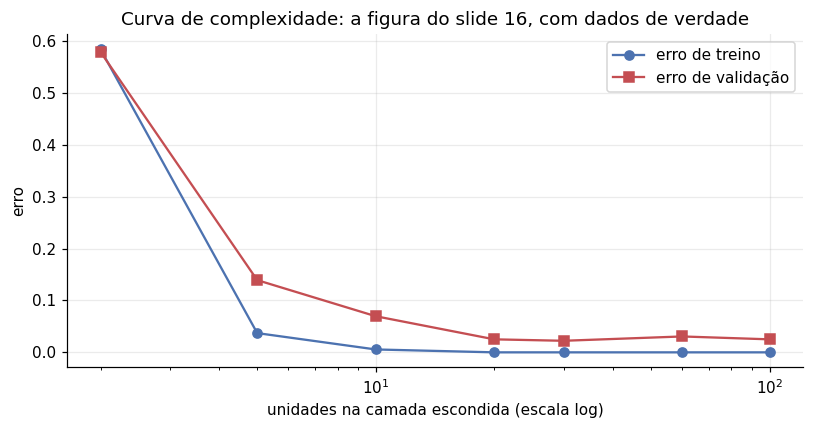

In [12]:
tabela["erro treino"] = 1 - tabela["acurácia treino"]
tabela["erro validação"] = 1 - tabela["acurácia validação"]
tabela["diagnóstico"] = [
    diagnostico(t, v, erro_otimo=0.0, tolerancia=0.02)
    for t, v in zip(tabela["erro treino"], tabela["erro validação"])
]
print(tabela[["unidades", "erro treino", "erro validação", "diagnóstico"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tabela["unidades"], tabela["erro treino"], "o-", color=CORES[0], label="erro de treino")
ax.plot(tabela["unidades"], tabela["erro validação"], "s-", color=CORES[3], label="erro de validação")
ax.set_xscale("log")
ax.set_xlabel("unidades na camada escondida (escala log)")
ax.set_ylabel("erro")
ax.set_title("Curva de complexidade: a figura do slide 16, com dados de verdade")
ax.legend()
plt.tight_layout()
plt.show()

🔎 **PARE E PENSE**: à esquerda do gráfico as duas curvas estão **juntas e altas** -
bias alto. À direita, a de treino colou no zero e a de validação estacionou num
patamar acima - variância. O ponto de operação é onde a curva de validação atinge o
mínimo, e não onde a de treino é menor (a de treino é sempre menor na maior rede).

### Mais dados ajudariam? A curva de aprendizado

O fluxograma do slide 20 sugere, para variância alta, "adquira mais dados". Antes de
gastar dinheiro anotando exemplos, dá para **prever** se isso resolveria: treine com
frações crescentes da base e veja se a curva de validação ainda está descendo.

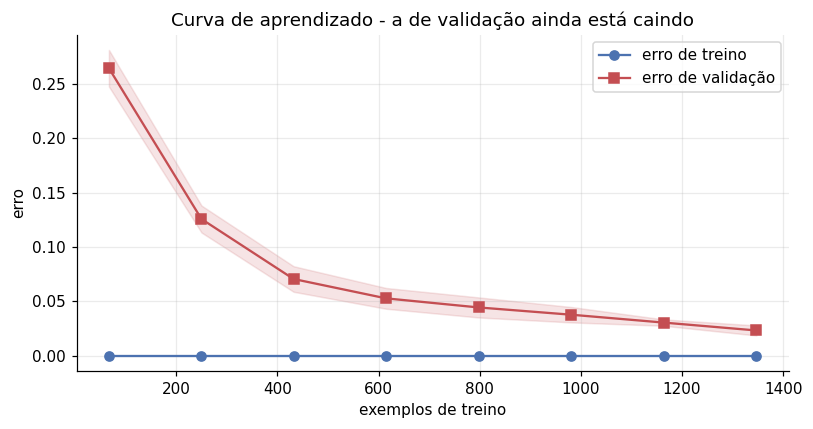

     67 exemplos:  erro treino 0.0000   erro validação 0.2643
    250 exemplos:  erro treino 0.0000   erro validação 0.1258
    432 exemplos:  erro treino 0.0000   erro validação 0.0707
    615 exemplos:  erro treino 0.0000   erro validação 0.0529
    798 exemplos:  erro treino 0.0000   erro validação 0.0445
    981 exemplos:  erro treino 0.0000   erro validação 0.0378
   1164 exemplos:  erro treino 0.0000   erro validação 0.0306
   1347 exemplos:  erro treino 0.0000   erro validação 0.0234


In [13]:
from sklearn.model_selection import learning_curve

tamanhos, notas_tr, notas_va = learning_curve(
    make_pipeline(StandardScaler(),
                  MLPClassifier(hidden_layer_sizes=(100,), activation="logistic",
                                max_iter=400, random_state=RANDOM_STATE)),
    X, y, train_sizes=np.linspace(0.05, 1.0, 8),
    cv=StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tamanhos, 1 - notas_tr.mean(axis=1), "o-", color=CORES[0], label="erro de treino")
ax.plot(tamanhos, 1 - notas_va.mean(axis=1), "s-", color=CORES[3], label="erro de validação")
ax.fill_between(tamanhos, 1 - notas_va.mean(axis=1) - notas_va.std(axis=1),
                1 - notas_va.mean(axis=1) + notas_va.std(axis=1),
                color=CORES[3], alpha=0.15)
ax.set_xlabel("exemplos de treino")
ax.set_ylabel("erro")
ax.set_title("Curva de aprendizado - a de validação ainda está caindo")
ax.legend()
plt.tight_layout()
plt.show()

for t, a, b in zip(tamanhos, 1 - notas_tr.mean(axis=1), 1 - notas_va.mean(axis=1)):
    print(f"  {t:5} exemplos:  erro treino {a:.4f}   erro validação {b:.4f}")

🎯 A curva de validação ainda cai no último ponto e a de treino está grudada no zero:
**mais dados ajudariam**. Se as duas curvas estivessem juntas e planas, mais dados não
mudariam nada - o caso seria de bias, e a resposta seria uma rede maior. A mesma
figura responde a duas perguntas diferentes.

O fluxograma do slide 20, em forma de tabela:

| diagnóstico | o que fazer |
|---|---|
| alto bias | rede maior (mais camadas / unidades), treinar por mais ciclos, outra arquitetura |
| alta variância | mais dados, **regularização**, outra arquitetura |
| os dois | os dois conjuntos de medidas, um de cada vez |
| nenhum | churrasco 🍖 |

As próximas cinco seções são sobre a palavra em negrito.

---
## 5. Regularização

A intuição do slide 22. Suponha um modelo com termos até $x^4$, que está decorando os
dados. Em vez de tirar os termos na mão, acrescente ao custo uma penalização enorme
sobre eles:

$$\min_\theta\ \frac{1}{2m}\sum_i (h(x^{(i)}) - y^{(i)})^2 + 1000\,\theta_3^2 + 1000\,\theta_4^2$$

Minimizar isso empurra $\theta_3$ e $\theta_4$ para quase zero, e o que sobra é
praticamente uma quadrática. Só que, na vida real, não sabemos **quais** parâmetros
encolher. A saída é penalizar todos de uma vez - menos $\theta_0$, que só desloca a
hipótese:

$$J(\theta) = -\frac{1}{m}\sum_i \left[y^{(i)}\log h(x^{(i)}) + (1 - y^{(i)})\log(1 - h(x^{(i)}))\right]
  + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2$$

### 🔨 IMPLEMENTE 3 - custo e gradiente regularizados

Partimos das funções da aula 04 e acrescentamos o termo. No gradiente, a derivada de
$\frac{\lambda}{2m}\theta_j^2$ é $\frac{\lambda}{m}\theta_j$ - e ela **não** se aplica
a $\theta_0$.

In [14]:
def custo_logistico(theta, Xb, y):
    """Entropia cruzada sem regularização (a da aula 04)."""
    EPS = 1e-12
    h = sigmoide(Xb @ theta)
    return float(-np.mean(y * np.log(h + EPS) + (1 - y) * np.log(1 - h + EPS)))


def gradiente_logistico(theta, Xb, y):
    """Gradiente sem regularização (o da aula 04)."""
    return Xb.T @ (sigmoide(Xb @ theta) - y) / len(y)


def custo_regularizado(theta, Xb, y, lam):
    """Entropia cruzada + (lam / 2m) * soma dos theta_j ao quadrado, j >= 1."""
    m = len(y)
    return custo_logistico(theta, Xb, y) + lam / (2 * m) * float(np.sum(theta[1:] ** 2))


def gradiente_regularizado(theta, Xb, y, lam):
    """Gradiente do custo acima. Devolve np.ndarray (n+1,)."""
    m = len(y)
    penalizacao = lam / m * np.asarray(theta, dtype=float).copy()
    penalizacao[0] = 0.0          # theta_0 fica de fora
    return gradiente_logistico(theta, Xb, y) + penalizacao

In [15]:
# A base: os pinguins da aula 03/04, agora com os DOIS atributos do bico.
CAMINHO_LOCAL = Path("../../dados/penguins.csv")
URL_FALLBACK = ("https://raw.githubusercontent.com/bmnogueira-ufms/IA-2026-02/"
                "main/dados/penguins.csv")
bruto = pd.read_csv(CAMINHO_LOCAL if CAMINHO_LOCAL.exists() else URL_FALLBACK)
pinguins = bruto.rename(columns={
    "species": "especie", "bill_length_mm": "bico_comprimento",
    "bill_depth_mm": "bico_profundidade"})
duas = pinguins[pinguins["especie"].isin(["Adelie", "Chinstrap"])].dropna(
    subset=["bico_comprimento", "bico_profundidade"])
y_ping = (duas["especie"] == "Chinstrap").astype(int).to_numpy()
X_ping = duas[["bico_comprimento", "bico_profundidade"]].to_numpy(dtype=float)
Xz_ping = (X_ping - X_ping.mean(axis=0)) / X_ping.std(axis=0)
Xb_ping = com_bias(Xz_ping)

# Conferência 1: contra a derivada numérica.
theta_t = np.array([0.2, -0.4, 0.7])
lam_t = 3.0
EPS = 1e-6
analitico = gradiente_regularizado(theta_t, Xb_ping, y_ping, lam_t)
numerico = np.array([
    (custo_regularizado(theta_t + EPS * np.eye(3)[j], Xb_ping, y_ping, lam_t)
     - custo_regularizado(theta_t - EPS * np.eye(3)[j], Xb_ping, y_ping, lam_t)) / (2 * EPS)
    for j in range(3)
])
assert np.allclose(analitico, numerico, atol=1e-8), \
    f"analítico {analitico} != numérico {numerico}"
# Conferência 2: com lam = 0, tem que ser exatamente o da aula 04.
assert np.allclose(gradiente_regularizado(theta_t, Xb_ping, y_ping, 0.0),
                   gradiente_logistico(theta_t, Xb_ping, y_ping)), \
    "com lambda = 0 nada deveria mudar"
# Conferência 3: theta_0 não pode ser penalizado.
so_bias = np.array([5.0, 0.0, 0.0])
assert np.isclose(custo_regularizado(so_bias, Xb_ping, y_ping, 100.0),
                  custo_logistico(so_bias, Xb_ping, y_ping)), \
    "theta_0 não entra na regularização"
print("OK - custo e gradiente regularizados corretos.")
print(f"analítico: {analitico.round(8)}")
print(f"numérico:  {numerico.round(8)}")

OK - custo e gradiente regularizados corretos.
analítico: [ 0.23250815 -0.44478483  0.12635039]
numérico:  [ 0.23250815 -0.44478483  0.12635039]


### O que $\lambda$ faz com os parâmetros

E, de quebra, a resposta à pergunta que ficou da aula 03: **o que é o `C` do
`LogisticRegression`?** É o inverso do $\lambda$ - a biblioteca parametriza a mesma
penalização ao contrário, $C = 1/\lambda$. Quanto **menor** o `C`, mais forte a
regularização.

In [16]:
def treina_regularizado(Xb, y, lam, alpha=0.3, iteracoes=15000):
    theta = np.zeros(Xb.shape[1])
    for _ in range(iteracoes):
        theta = theta - alpha * gradiente_regularizado(theta, Xb, y, lam)
    return theta


from sklearn.linear_model import LogisticRegression

linhas = []
for lam in [0.0, 0.1, 1.0, 10.0, 100.0, 500.0]:
    theta_lam = treina_regularizado(Xb_ping, y_ping, lam)
    acertos = ((sigmoide(Xb_ping @ theta_lam) >= 0.5).astype(int) == y_ping).mean()
    linhas.append({
        "lambda": lam,
        "theta_0": theta_lam[0], "theta_1": theta_lam[1], "theta_2": theta_lam[2],
        "||theta_{1..n}||": np.linalg.norm(theta_lam[1:]),
        "acurácia treino": acertos,
    })
    if lam > 0:   # a correspondência com o scikit-learn
        sk = LogisticRegression(C=1.0 / lam, max_iter=20000).fit(Xz_ping, y_ping)
        assert np.allclose(theta_lam, np.r_[sk.intercept_, sk.coef_.ravel()], atol=1e-2), \
            f"lambda = {lam} deveria equivaler a C = {1 / lam}"

print(pd.DataFrame(linhas).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nOK - para todo lambda > 0, o nosso theta bate com LogisticRegression(C = 1/lambda).")
print("É essa a tradução: C grande = quase sem regularização; C pequeno = muita.")

  lambda  theta_0  theta_1  theta_2  ||theta_{1..n}||  acurácia treino
  0.0000  -4.4747  10.9180  -4.2333           11.7099           0.9726
  0.1000  -3.1120   7.3801  -2.6969            7.8575           0.9726
  1.0000  -1.9535   4.1748  -1.2935            4.3706           0.9680
 10.0000  -1.2073   1.9773  -0.4046            2.0183           0.9589
100.0000  -0.8532   0.5882  -0.0320            0.5891           0.8311
500.0000  -0.8023   0.1573   0.0016            0.1573           0.6895

OK - para todo lambda > 0, o nosso theta bate com LogisticRegression(C = 1/lambda).
É essa a tradução: C grande = quase sem regularização; C pequeno = muita.


🔎 **PARE E PENSE**: na última linha, com $\lambda = 500$, todos os $\theta_j$ estão
perto de zero e a acurácia caiu para **exatamente** o erro majoritário - o modelo
virou o classificador que responde sempre a classe mais comum. É o aviso do slide 26:
$\lambda$ grande demais **desconsidera todos os termos** da hipótese e produz
*underfitting*. Regularização não é "quanto mais, melhor" - é mais um hiperparâmetro
para escolher na validação.

### L1 × L2

A penalização que usamos é a **L2**, a norma euclidiana $\|\theta\|_2^2$. Existe a
**L1**, $\sum_j |\theta_j|$, que o slide 25 diz ser "menos indicada" porque deixa o
vetor de parâmetros **esparso**. Vamos ver o que isso quer dizer, com um modelo
polinomial de grau 6 (27 parâmetros).

In [17]:
from sklearn.preprocessing import PolynomialFeatures

Z = make_pipeline(PolynomialFeatures(6, include_bias=False), StandardScaler()) \
    .fit_transform(Xz_ping)
print(f"{Z.shape[1]} atributos polinomiais.\n")
for penalidade in ["l2", "l1"]:
    m = LogisticRegression(penalty=penalidade, C=0.05, solver="liblinear",
                           max_iter=5000).fit(Z, y_ping)
    coef = m.coef_.ravel()
    print(f"  {penalidade.upper()}: {int((np.abs(coef) < 1e-8).sum()):2} coeficientes "
          f"exatamente ZERO de {len(coef)}   |   acurácia {m.score(Z, y_ping):.2%}")

print("\nA L2 encolhe todo mundo, mas não zera ninguém: todos os atributos continuam")
print("participando um pouquinho. A L1 zera a maioria - ela ESCOLHE atributos. Por isso")
print("a L1 é ótima quando o objetivo é selecionar variáveis, e pior quando o objetivo")
print("é só controlar a complexidade, que é o caso das redes neurais.")

27 atributos polinomiais.

  L2:  0 coeficientes exatamente ZERO de 27   |   acurácia 94.98%
  L1: 26 coeficientes exatamente ZERO de 27   |   acurácia 95.43%

A L2 encolhe todo mundo, mas não zera ninguém: todos os atributos continuam
participando um pouquinho. A L1 zera a maioria - ela ESCOLHE atributos. Por isso
a L1 é ótima quando o objetivo é selecionar variáveis, e pior quando o objetivo
é só controlar a complexidade, que é o caso das redes neurais.


---
## 6. Regularização em redes neurais: *weight decay*

Numa rede, o custo ganha o mesmo termo, somado sobre **todas** as matrizes $\Theta$
(slide 35):

$$J(\Theta) = -\frac{1}{m}\sum_{i}\sum_{k}\left[\cdots\right]
  + \frac{\lambda}{2m}\sum_{l}\sum_{i}\sum_{j}\left(\Theta_{ji}^{(l)}\right)^2$$

e a atualização vira
$\Theta_{ij}^{(l)} := \Theta_{ij}^{(l)} - \alpha\left(\frac{\partial J}{\partial \Theta_{ij}^{(l)}} + \frac{\lambda}{m}\Theta_{ij}^{(l)}\right)$.
Reorganizando, cada passo multiplica o peso por $\left(1 - \frac{\alpha\lambda}{m}\right)$
antes de aplicar o gradiente: os pesos **encolhem sozinhos** a cada iteração. Daí o
apelido **weight decay**.

O argumento dos slides 39 e 40 é elegante: $\lambda$ grande empurra $\Theta$ para
perto de zero; com $\Theta$ pequeno, $z = \Theta^T a$ fica na **faixa central** da
sigmoide, que é praticamente uma reta; e uma rede de camadas quase lineares só sabe
desenhar fronteiras quase lineares. Regularizar não "desliga" a rede - ela volta
gradualmente a ser uma regressão logística.

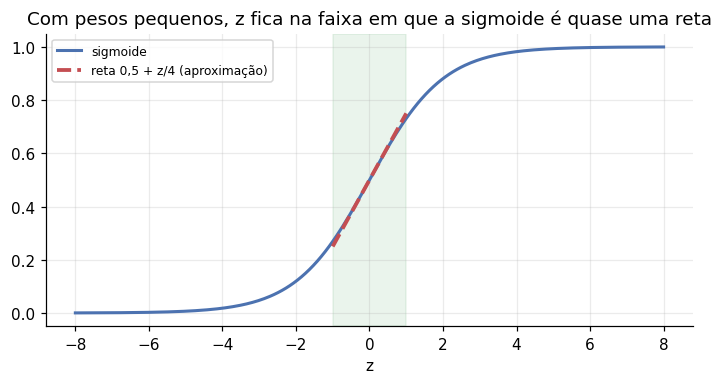

In [18]:
zs = np.linspace(-8, 8, 300)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(zs, sigmoide(zs), color=CORES[0], lw=2, label="sigmoide")
faixa = np.linspace(-1, 1, 50)
ax.plot(faixa, 0.5 + faixa / 4, color=CORES[3], lw=2.5, ls="--",
        label="reta 0,5 + z/4 (aproximação)")
ax.axvspan(-1, 1, color=CORES[2], alpha=0.12)
ax.set_xlabel("z")
ax.set_title("Com pesos pequenos, z fica na faixa em que a sigmoide é quase uma reta")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.datasets import make_moons

# Uma base 2D com bastante ruído - overfitting aparece fácil.
X_luas, y_luas = make_moons(n_samples=200, noise=0.35, random_state=RANDOM_STATE)
X_luas_tr, X_luas_te, y_luas_tr, y_luas_te = train_test_split(
    X_luas, y_luas, test_size=0.5, random_state=RANDOM_STATE, stratify=y_luas)

# No MLPClassifier, o parâmetro de regularização L2 se chama `alpha` (não confundir
# com a taxa de aprendizado, que lá se chama `learning_rate_init`).
LAMBDAS = [1e-6, 0.01, 0.1, 1.0, 3.0, 10.0]
linhas, modelos = [], {}
for lam in LAMBDAS:
    m = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(80, 80), activation="logistic", alpha=lam,
                      solver="lbfgs", max_iter=8000, random_state=RANDOM_STATE),
    ).fit(X_luas_tr, y_luas_tr)
    modelos[lam] = m
    norma = float(np.sqrt(sum((c ** 2).sum() for c in m[-1].coefs_)))
    linhas.append({
        "lambda (alpha)": lam,
        "erro treino": 1 - m.score(X_luas_tr, y_luas_tr),
        "erro teste": 1 - m.score(X_luas_te, y_luas_te),
        "||Theta||": norma,
    })
tabela_lam = pd.DataFrame(linhas)
tabela_lam["diagnóstico"] = [
    diagnostico(t, v, erro_otimo=0.10, tolerancia=0.05)
    for t, v in zip(tabela_lam["erro treino"], tabela_lam["erro teste"])
]
print(tabela_lam.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\n(erro ótimo estimado em 10%: a base foi gerada com noise=0.35, então uma parte")
print("dos pontos está do lado 'errado' por construção e ninguém acerta.)")

 lambda (alpha)  erro treino  erro teste  ||Theta||    diagnóstico
         0.0000       0.0000      0.2100   418.1733 alta variância
         0.0100       0.0100      0.2400    33.1527 alta variância
         0.1000       0.0700      0.1700    13.2442 alta variância
         1.0000       0.2000      0.1700     4.9112      alto bias
         3.0000       0.5000      0.5000     0.0155      alto bias
        10.0000       0.5000      0.5000     0.0016      alto bias

(erro ótimo estimado em 10%: a base foi gerada com noise=0.35, então uma parte
dos pontos está do lado 'errado' por construção e ninguém acerta.)


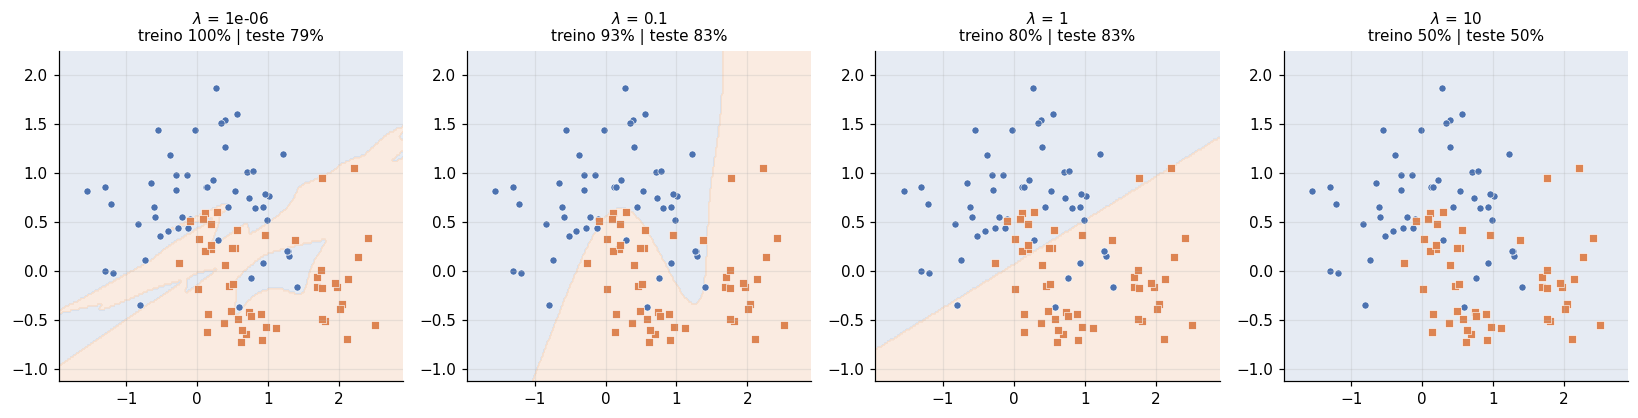

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.9))
for ax, lam in zip(axes, [1e-6, 0.1, 1.0, 10.0]):
    m = modelos[lam]
    plota_regioes(m, X_luas_tr, y_luas_tr, ax,
                  f"$\\lambda$ = {lam:g}\ntreino {m.score(X_luas_tr, y_luas_tr):.0%} | "
                  f"teste {m.score(X_luas_te, y_luas_te):.0%}")
plt.tight_layout()
plt.show()

🎯 Da esquerda para a direita: a fronteira começa cheia de ilhas e reentrâncias -
a rede contornando ponto a ponto - e vai **alisando** até virar quase uma reta. O
$\|\Theta\|$ na tabela despenca junto. O melhor teste não está em nenhum dos extremos.

---
## 7. Dropout

A ideia do slide 41 parece sabotagem: a cada passo do treinamento, **desligue algumas
unidades ao acaso**. Cada unidade tem uma probabilidade $p$ de continuar na rede
naquele passo; as outras viram zero.

A justificativa está no slide 42: se uma unidade pode sumir a qualquer momento,
nenhuma outra pode depender só dela. A rede é obrigada a **espalhar** a computação, e
soluções espalhadas generalizam melhor.

O `MLPClassifier` não tem dropout, então usamos a rede da aula 04 - forward e
backpropagation em NumPy, agora com uma máscara aleatória nas ativações escondidas.
O código vem pronto; o que interessa é o experimento.

    regularização  acurácia treino  acurácia teste
sem regularização            0.970           0.780
  L2 (lambda = 3)            0.760           0.840
dropout (p = 0,6)            0.940           0.850


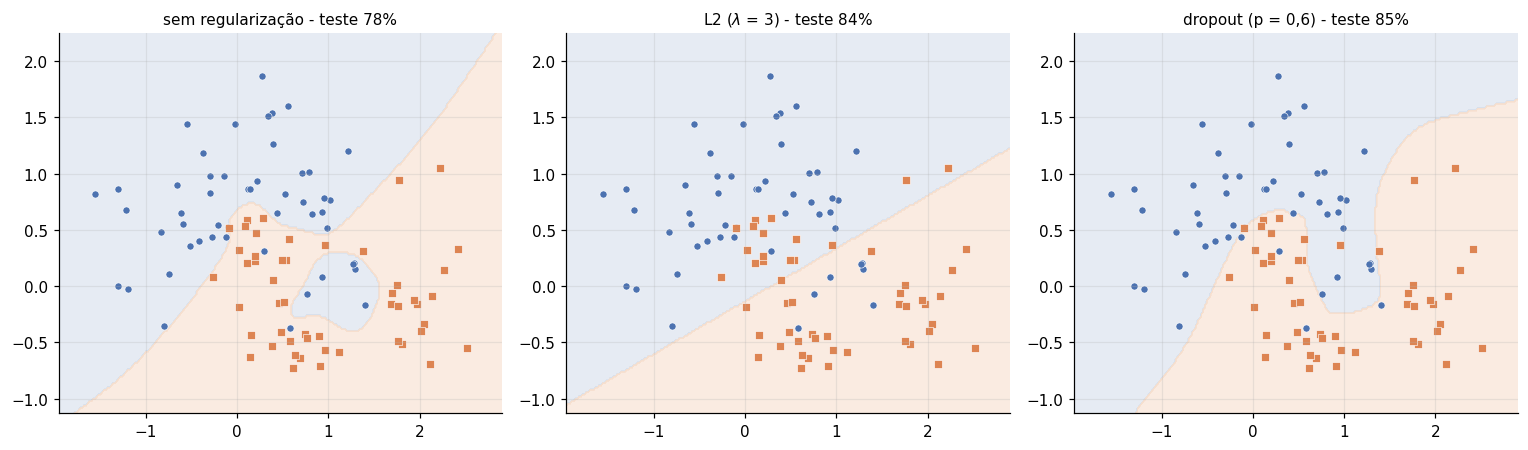

In [21]:
def treina_rede(X, y, n_escondidas=40, alpha=2.0, lam=0.0, p_manter=1.0,
                passos=6000, semente=1):
    """Rede 2-n-1 treinada por backpropagation, com L2 e/ou dropout opcionais."""
    gerador = np.random.default_rng(semente)
    m, Y = len(y), y.reshape(-1, 1)
    T1 = gerador.normal(0, 0.5, (X.shape[1] + 1, n_escondidas))
    T2 = gerador.normal(0, 0.5, (n_escondidas + 1, 1))

    for _ in range(passos):
        A1 = com_bias(X)
        A2 = sigmoide(A1 @ T1)
        if p_manter < 1.0:
            # Dropout invertido: sorteia quem fica e divide por p, para que a soma
            # esperada das ativações não mude quando as unidades voltam no teste.
            mascara = (gerador.random(A2.shape) < p_manter) / p_manter
            A2 = A2 * mascara
        else:
            mascara = None

        A2b = com_bias(A2)
        H = sigmoide(A2b @ T2)

        delta3 = H - Y
        G2 = A2b.T @ delta3 / m
        G2[1:] += lam / m * T2[1:]                 # weight decay (bias de fora)

        delta2 = (delta3 @ T2[1:].T) * A2 * (1 - A2)
        if mascara is not None:
            delta2 = delta2 * mascara              # unidade desligada não recebe erro
        G1 = A1.T @ delta2 / m
        G1[1:] += lam / m * T1[1:]

        T1, T2 = T1 - alpha * G1, T2 - alpha * G2
    return T1, T2


def prediz_rede(X, T1, T2):
    """No teste, TODAS as unidades participam - dropout só age no treinamento."""
    return (sigmoide(com_bias(sigmoide(com_bias(X) @ T1)) @ T2).ravel() >= 0.5).astype(int)


class RedeManual:
    """Embrulho mínimo para o plota_regioes conseguir chamar .predict()."""

    def __init__(self, T1, T2, escalador):
        self.T1, self.T2, self.escalador = T1, T2, escalador

    def predict(self, X):
        return prediz_rede(self.escalador.transform(X), self.T1, self.T2)


escalador = StandardScaler().fit(X_luas_tr)
A_tr, A_te = escalador.transform(X_luas_tr), escalador.transform(X_luas_te)

CONFIGS = {
    "sem regularização": dict(),
    "L2 ($\\lambda$ = 3)": dict(lam=3.0),
    "dropout (p = 0,6)": dict(p_manter=0.6),
}
redes, resumo = {}, []
for nome, kwargs in CONFIGS.items():
    T1, T2 = treina_rede(A_tr, y_luas_tr, **kwargs)
    redes[nome] = (T1, T2)
    resumo.append({
        "regularização": nome.replace("$\\lambda$", "lambda"),
        "acurácia treino": (prediz_rede(A_tr, T1, T2) == y_luas_tr).mean(),
        "acurácia teste": (prediz_rede(A_te, T1, T2) == y_luas_te).mean(),
    })
print(pd.DataFrame(resumo).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (nome, (T1, T2)) in zip(axes, redes.items()):
    modelo = RedeManual(T1, T2, escalador)
    acc = (prediz_rede(A_te, T1, T2) == y_luas_te).mean()
    plota_regioes(modelo, X_luas_tr, y_luas_tr, ax, f"{nome} - teste {acc:.0%}")
plt.tight_layout()
plt.show()

### A prova de que dropout espalha a computação

O argumento do slide 42 é testável. Treine as duas redes, depois **zere uma unidade
escondida de cada vez** e veja quanto a acurácia cai. Se a computação estiver
concentrada, tirar a unidade errada derruba tudo.

In [22]:
comparacao = []
for nome in ["sem regularização", "dropout (p = 0,6)"]:
    T1, T2 = redes[nome]
    base = (prediz_rede(A_te, T1, T2) == y_luas_te).mean()
    quedas = []
    for j in range(T1.shape[1]):
        T2_sem = T2.copy()
        T2_sem[j + 1] = 0.0          # +1 por causa da linha do bias
        quedas.append(base - (prediz_rede(A_te, T1, T2_sem) == y_luas_te).mean())
    quedas = np.array(quedas)
    comparacao.append({
        "rede": nome.replace("$\\lambda$", "lambda"),
        "acurácia": base,
        "queda média (pp)": quedas.mean() * 100,
        "pior unidade (pp)": quedas.max() * 100,
    })
print(pd.DataFrame(comparacao).to_string(index=False, float_format=lambda v: f"{v:.2f}"))

             rede  acurácia  queda média (pp)  pior unidade (pp)
sem regularização      0.78             -0.90              20.00
dropout (p = 0,6)      0.85             -0.33               2.00


🎯 Sem regularização, existe **uma** unidade cuja remoção derruba a acurácia em vários
pontos - a rede pendurou boa parte da decisão nela. Com dropout, a pior unidade custa
quase nada: o trabalho está distribuído, exatamente como o slide promete.

Uma ressalva honesta: dropout e L2 chegam ao mesmo lugar por caminhos diferentes. A L2
**encolhe** os pesos (olhe a coluna `||Theta||` da seção 6); o dropout não
necessariamente encolhe nada - ele impõe **redundância**. A frase do slide 42
("efeito similar à L2") vale para o resultado - hipóteses mais simples, menos
overfitting -, não para o mecanismo.

---
## 8. Data augmentation

Voltemos ao desastre da seção 2: um pixel de deslocamento derrubou a rede de 96% para
37%. O fluxograma manda "adquirir mais dados", e a curva de aprendizado concordou. Mas
anotar dados custa caro - e o slide 43 sugere **fabricá-los** a partir dos que já
existem, com transformações que não mudam o rótulo.

Um 7 deslocado um pixel continua sendo um 7. Então: quatro cópias deslocadas de cada
imagem de treino, e o conjunto quintuplica.

In [23]:
DESLOCAMENTOS = [(0, 1), (0, -1), (1, 0), (-1, 0)]
X_aum = np.vstack([X_tr] + [desloca(X_tr, dy, dx) for dy, dx in DESLOCAMENTOS])
y_aum = np.tile(y_tr, 1 + len(DESLOCAMENTOS))
print(f"treino original: {X_tr.shape[0]} imagens")
print(f"treino aumentado: {X_aum.shape[0]} imagens (nenhuma anotação nova)")

rede_aum = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(30,), activation="logistic",
                  max_iter=600, random_state=RANDOM_STATE),
).fit(X_aum, y_aum)

linhas = []
for nome, modelo in [("treino original", rede), ("treino aumentado", rede_aum)]:
    linhas.append({
        "rede": nome,
        "teste original": modelo.score(X_te, y_te),
        "teste desl. (0,1)": modelo.score(desloca(X_te, 0, 1), y_te),
        "teste desl. (1,1)": modelo.score(desloca(X_te, 1, 1), y_te),
    })
print()
print(pd.DataFrame(linhas).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

treino original: 1078 imagens
treino aumentado: 5390 imagens (nenhuma anotação nova)



            rede  teste original  teste desl. (0,1)  teste desl. (1,1)
 treino original          0.9667             0.3750             0.1361
treino aumentado          0.9333             0.8917             0.4528


🔎 **PARE E PENSE**: no teste deslocado, a rede aumentada vai de ~37% para ~89%. Mas
olhe a primeira coluna: no teste **original**, ela ficou um pouco **pior**. Por quê? E
qual das duas você entregaria para um sistema que lê formulários digitalizados?

(Resposta curta: pedimos à rede que resolva um problema maior - reconhecer o dígito
em qualquer posição - com a mesma capacidade de antes, então ela gasta parte dela com
a invariância e perde um pouco de precisão no caso fácil. Em troca, ela deixa de
quebrar quando o mundo real sai um pixel do lugar. Para digitalização, a segunda, sem
hesitar.)

---
## 9. Early stopping

O último truque do slide 44, e o mais barato: **parar antes**. Enquanto o treinamento
avança, $\|\Theta\|$ cresce e a hipótese fica mais flexível; o custo de treino cai
sempre, mas o de validação cai, atinge um mínimo e volta a subir. Parar no mínimo é
uma forma de regularização - só que em vez de penalizar os pesos grandes, a gente
simplesmente não dá tempo para eles aparecerem.

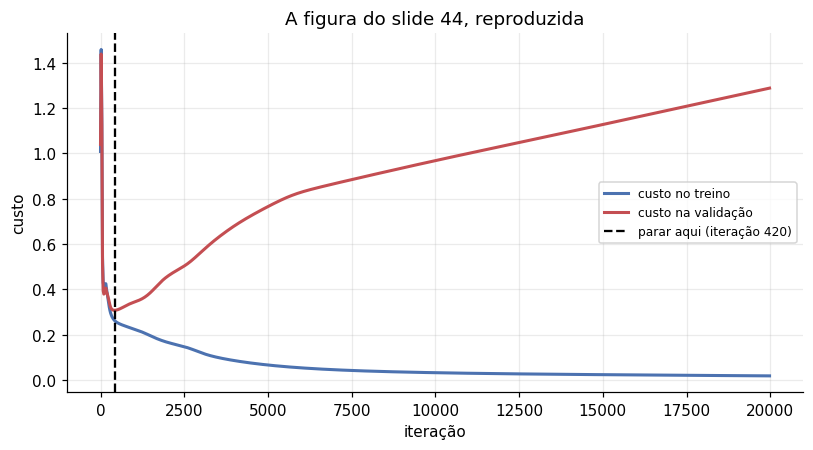

Melhor iteração (mínimo do custo de validação): 420
  ali:   custo treino 0.2619   validação 0.3071
  no fim: custo treino 0.0178   validação 1.2874

Treinar 19560 iterações a mais melhorou o treino e PIOROU a validação em 0.98.


In [24]:
def custo_rede(X, y, T1, T2):
    EPS = 1e-12
    h = sigmoide(com_bias(sigmoide(com_bias(X) @ T1)) @ T2).ravel()
    return float(-np.mean(y * np.log(h + EPS) + (1 - y) * np.log(1 - h + EPS)))


def treina_com_historico(X, y, Xv, yv, n_escondidas=60, alpha=2.0, passos=20000,
                         intervalo=20, semente=1):
    """Treina registrando o custo de treino e o de validação a cada `intervalo` passos."""
    gerador = np.random.default_rng(semente)
    m, Y = len(y), y.reshape(-1, 1)
    T1 = gerador.normal(0, 0.5, (X.shape[1] + 1, n_escondidas))
    T2 = gerador.normal(0, 0.5, (n_escondidas + 1, 1))
    hist_tr, hist_va, iteracoes = [], [], []
    for passo in range(passos):
        if passo % intervalo == 0:
            hist_tr.append(custo_rede(X, y, T1, T2))
            hist_va.append(custo_rede(Xv, yv, T1, T2))
            iteracoes.append(passo)
        A1 = com_bias(X)
        A2 = sigmoide(A1 @ T1)
        A2b = com_bias(A2)
        H = sigmoide(A2b @ T2)
        delta3 = H - Y
        G2 = A2b.T @ delta3 / m
        delta2 = (delta3 @ T2[1:].T) * A2 * (1 - A2)
        G1 = A1.T @ delta2 / m
        T1, T2 = T1 - alpha * G1, T2 - alpha * G2
    return np.array(iteracoes), np.array(hist_tr), np.array(hist_va)


iteracoes, hist_tr, hist_va = treina_com_historico(A_tr, y_luas_tr, A_te, y_luas_te)
melhor = int(np.argmin(hist_va))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(iteracoes, hist_tr, color=CORES[0], lw=2, label="custo no treino")
ax.plot(iteracoes, hist_va, color=CORES[3], lw=2, label="custo na validação")
ax.axvline(iteracoes[melhor], color="black", ls="--", lw=1.5,
           label=f"parar aqui (iteração {iteracoes[melhor]})")
ax.set_xlabel("iteração")
ax.set_ylabel("custo")
ax.set_title("A figura do slide 44, reproduzida")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Melhor iteração (mínimo do custo de validação): {iteracoes[melhor]}")
print(f"  ali:   custo treino {hist_tr[melhor]:.4f}   validação {hist_va[melhor]:.4f}")
print(f"  no fim: custo treino {hist_tr[-1]:.4f}   validação {hist_va[-1]:.4f}")
print(f"\nTreinar {iteracoes[-1] - iteracoes[melhor]} iterações a mais melhorou o treino"
      f" e PIOROU a validação em {hist_va[-1] - hist_va[melhor]:.2f}.")

In [25]:
# O scikit-learn faz isso sozinho: early_stopping separa uma fatia de validação e
# para quando ela deixa de melhorar por n_iter_no_change épocas seguidas.
for parar in [False, True]:
    m = MLPClassifier(hidden_layer_sizes=(100,), activation="logistic", max_iter=1000,
                      early_stopping=parar, validation_fraction=0.2,
                      n_iter_no_change=10, random_state=RANDOM_STATE)
    escalador_dig = StandardScaler().fit(X_tr)
    m.fit(escalador_dig.transform(X_tr), y_tr)
    print(f"early_stopping={str(parar):5}  épocas: {m.n_iter_:4}   "
          f"treino {m.score(escalador_dig.transform(X_tr), y_tr):.4f}   "
          f"teste {m.score(escalador_dig.transform(X_te), y_te):.4f}")
print("\nAqui ele PAROU CEDO DEMAIS: economizou épocas e perdeu acurácia. A curva de")
print("validação dos dígitos é plana perto do fim, e 10 épocas sem melhora é um critério")
print("apertado demais para ela. Early stopping não é ganho automático - os parâmetros")
print("`n_iter_no_change` e `validation_fraction` também precisam ser escolhidos.")

early_stopping=False  épocas:  320   treino 1.0000   teste 0.9667


early_stopping=True   épocas:   60   treino 0.9555   teste 0.9250

Aqui ele PAROU CEDO DEMAIS: economizou épocas e perdeu acurácia. A curva de
validação dos dígitos é plana perto do fim, e 10 épocas sem melhora é um critério
apertado demais para ela. Early stopping não é ganho automático - os parâmetros
`n_iter_no_change` e `validation_fraction` também precisam ser escolhidos.


---
# Exercícios

Os três exercícios vêm com o **código pronto**. O trabalho é rodar, **ler os
resultados** e responder às perguntas nas células de markdown - com frases, não com
números soltos. Os exercícios 1 e 2 usam a sua `diagnostico` da IMPLEMENTE 2.

## Exercício 1 - o preço de escolher olhando o teste

De volta à base **Heart Disease** da aula 01: 303 pacientes da Cleveland Clinic, 13
atributos clínicos, e a pergunta é se há doença cardíaca.

Base pequena, muitos hiperparâmetros: o cenário em que os erros desta aula custam mais
caro. Vamos fazer as duas coisas - a errada e a certa - e comparar os números.

- **Referência:** JANOSI, A.; STEINBRUNN, W.; PFISTERER, M.; DETRANO, R. *Heart
  Disease*. UCI Machine Learning Repository, 1988.

In [26]:
from sklearn.impute import SimpleImputer

CAMINHO_HEART = Path("../../dados/heart-cleveland.csv")
URL_HEART = ("https://raw.githubusercontent.com/bmnogueira-ufms/IA-2026-02/"
             "main/dados/heart-cleveland.csv")
coracao = pd.read_csv(CAMINHO_HEART if CAMINHO_HEART.exists() else URL_HEART)

y_cor = (coracao["AHD"] == "Yes").astype(int).to_numpy()
X_cor = pd.get_dummies(coracao.drop(columns=["AHD"]), drop_first=True).astype(float)
X_cor = SimpleImputer(strategy="median").fit_transform(X_cor)
print(f"{X_cor.shape[0]} pacientes x {X_cor.shape[1]} atributos (após one-hot)")
print(f"doentes: {y_cor.sum()}   saudáveis: {(1 - y_cor).sum()}")

303 pacientes x 16 atributos (após one-hot)
doentes: 139   saudáveis: 164


In [27]:
# O JEITO ERRADO: treinar 9 configurações e escolher a melhor no conjunto de teste.
X_cor_tr, X_cor_te, y_cor_tr, y_cor_te = train_test_split(
    X_cor, y_cor, test_size=0.3, random_state=RANDOM_STATE, stratify=y_cor)

UNIDADES = [(2,), (5,), (20,)]
LAMBDAS_COR = [0.01, 1.0, 10.0]

linhas = []
for camada in UNIDADES:
    for lam in LAMBDAS_COR:
        m = make_pipeline(
            StandardScaler(),
            MLPClassifier(hidden_layer_sizes=camada, activation="logistic", alpha=lam,
                          max_iter=1000, random_state=RANDOM_STATE),
        ).fit(X_cor_tr, y_cor_tr)
        linhas.append({
            "unidades": camada[0], "lambda": lam,
            "acurácia treino": m.score(X_cor_tr, y_cor_tr),
            "acurácia teste": m.score(X_cor_te, y_cor_te),
        })
resultado = pd.DataFrame(linhas).sort_values("acurácia teste", ascending=False)
# Erro ótimo estimado em 15%: é onde os melhores resultados publicados para esta base
# costumam parar - nenhum modelo acerta muito além de 85% aqui.
resultado["diagnóstico"] = [
    diagnostico(1 - t, 1 - v, erro_otimo=0.15, tolerancia=0.05)
    for t, v in zip(resultado["acurácia treino"], resultado["acurácia teste"])
]
print(resultado.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nMelhor acurácia vista no teste: {resultado['acurácia teste'].max():.2%}")

 unidades  lambda  acurácia treino  acurácia teste                  diagnóstico
       20  1.0000           0.8396          0.8681 baixo bias e baixa variância
        5  1.0000           0.8396          0.8571 baixo bias e baixa variância
       20  0.0100           0.8538          0.8462 baixo bias e baixa variância
        2  1.0000           0.8679          0.8462 baixo bias e baixa variância
        2  0.0100           0.8632          0.8352 baixo bias e baixa variância
        5  0.0100           0.8585          0.8352 baixo bias e baixa variância
        2 10.0000           0.5425          0.5385                    alto bias
        5 10.0000           0.5425          0.5385                    alto bias
       20 10.0000           0.5425          0.5385                    alto bias

Melhor acurácia vista no teste: 86.81%


In [28]:
# O JEITO CERTO: validação cruzada aninhada sobre a base inteira.
grade_cor = {
    "mlpclassifier__hidden_layer_sizes": UNIDADES,
    "mlpclassifier__alpha": LAMBDAS_COR,
}
base_cor = make_pipeline(
    StandardScaler(),
    MLPClassifier(activation="logistic", max_iter=1000, random_state=RANDOM_STATE),
)
busca_cor = GridSearchCV(base_cor, grade_cor,
                         cv=StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE),
                         n_jobs=-1)
t0 = time.time()
aninhada_cor = cross_val_score(
    busca_cor, X_cor, y_cor,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
print(f"Acurácia por fold externo: {aninhada_cor.round(4)}")
print(f"Estimativa honesta: {aninhada_cor.mean():.2%} "
      f"(desvio {aninhada_cor.std():.2%}, {time.time() - t0:.0f} s)")
print(f"\nDiferença para o 'melhor no teste': "
      f"{(resultado['acurácia teste'].max() - aninhada_cor.mean()) * 100:.1f} pontos.")

Acurácia por fold externo: [0.8852 0.7049 0.6066 0.8333 0.8833]
Estimativa honesta: 78.27% (desvio 10.98%, 23 s)

Diferença para o 'melhor no teste': 8.5 pontos.


**Responda:**

a) Quantos pontos percentuais separam "a melhor acurácia que vimos no teste" da
   estimativa da validação cruzada aninhada? Qual dos dois números você escreveria
   num relatório - e por quê?

b) Olhe a acurácia de cada **fold externo** da aninhada. Qual é a amplitude entre o
   pior e o melhor? O que isso diz sobre confiar num número obtido de uma única
   divisão treino/teste nesta base?

c) Com $\lambda = 10$, todas as arquiteturas dão exatamente a mesma acurácia, e ela é
   baixa. Use a coluna `diagnóstico` e explique o que aconteceu com esses modelos.
   (Dica: compare com a proporção de saudáveis na base.)

d) A tabela mostra que a rede de **2 unidades** compete de igual para igual com a de
   20. O que isso sugere sobre a dificuldade deste problema, e o que a Navalha de
   Ockham da aula 01 recomendaria?

🎯 **Conclusão do Exercício 1**

a) São cerca de **8,5 pontos** de diferença (≈ 87% contra ≈ 78%). O número honesto é
   o da aninhada. O 87% é a melhor de nove medidas ruidosas escolhida **depois** de
   ver o resultado - metade mérito, metade sorte daquele sorteio. Escrever 87% num
   relatório é prometer um desempenho que o sistema não vai entregar em produção; e o
   erro não é pequeno, porque 8 pontos numa aplicação clínica são muitos pacientes.

b) A amplitude passa de **25 pontos** (de ~61% a ~89%, dependendo do fold). Com 303
   pacientes, cada fold de teste tem ~60 pessoas, e trocar uma dúzia de casos muda
   tudo. Ou seja: qualquer número vindo de **uma** divisão desta base é quase ruído
   puro. É exatamente o caso em que os slides 13 e 14 mandam usar validação cruzada -
   e reportar o desvio junto com a média, nunca a média sozinha.

c) Diagnóstico de **alto bias** nas três. Com $\lambda = 10$ a penalização domina o
   custo, todos os $\Theta$ vão para perto de zero e a rede volta a ser praticamente
   linear - e, no limite, constante. Repare que a acurácia resultante (~54%) é
   exatamente a proporção de saudáveis: o modelo virou o **classificador majoritário**
   da aula 01, que responde sempre a mesma coisa. Regularização demais não é
   "segurança extra", é destruir a hipótese.

d) Sugere que o problema é quase **linearmente separável** nos 16 atributos: não há
   estrutura complexa o bastante para justificar 20 unidades. A Navalha de Ockham
   recomenda a rede de 2 unidades - mesmo desempenho, muito menos parâmetros, muito
   menos chance de decorar ruído e muito mais fácil de defender diante de um
   cardiologista. Em dados tabulares pequenos esse é o padrão, e não a exceção.

## Exercício 2 - escolhendo $\lambda$ com validação cruzada

A seção 6 varreu $\lambda$ com uma única divisão treino/teste. Agora, do jeito certo:
`validation_curve` treina e avalia por validação cruzada para cada valor do parâmetro.

 lambda  erro treino  erro validação  desvio (validação)                  diagnóstico
 0.0001       0.0000          0.0234              0.0046               alta variância
 0.0100       0.0000          0.0234              0.0046               alta variância
 0.1000       0.0009          0.0217              0.0043               alta variância
 1.0000       0.0154          0.0328              0.0058 baixo bias e baixa variância
10.0000       0.1284          0.1369              0.0059                    alto bias


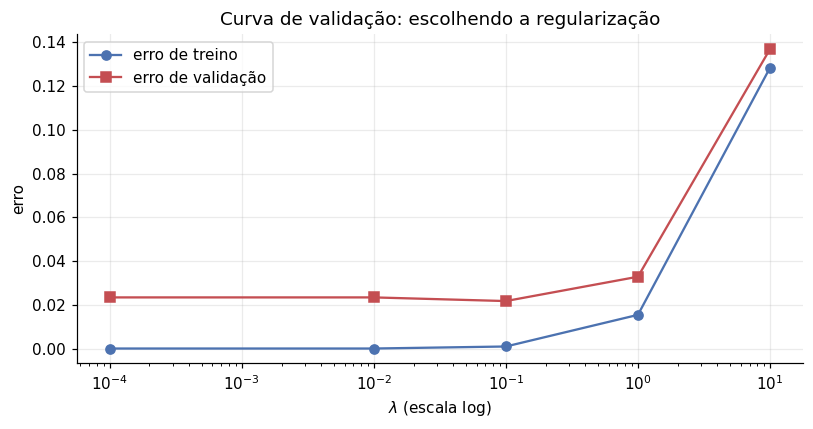

In [29]:
from sklearn.model_selection import validation_curve

LAMBDAS_DIG = [1e-4, 1e-2, 0.1, 1.0, 10.0]
notas_tr, notas_va = validation_curve(
    make_pipeline(StandardScaler(),
                  MLPClassifier(hidden_layer_sizes=(100,), activation="logistic",
                                max_iter=300, random_state=RANDOM_STATE)),
    X, y, param_name="mlpclassifier__alpha", param_range=LAMBDAS_DIG,
    cv=StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)

curva = pd.DataFrame({
    "lambda": LAMBDAS_DIG,
    "erro treino": 1 - notas_tr.mean(axis=1),
    "erro validação": 1 - notas_va.mean(axis=1),
    "desvio (validação)": notas_va.std(axis=1),
})
curva["diagnóstico"] = [
    diagnostico(t, v, erro_otimo=0.0, tolerancia=0.02)
    for t, v in zip(curva["erro treino"], curva["erro validação"])
]
print(curva.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(LAMBDAS_DIG, curva["erro treino"], "o-", color=CORES[0], label="erro de treino")
ax.plot(LAMBDAS_DIG, curva["erro validação"], "s-", color=CORES[3], label="erro de validação")
ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$ (escala log)")
ax.set_ylabel("erro")
ax.set_title("Curva de validação: escolhendo a regularização")
ax.legend()
plt.tight_layout()
plt.show()

**Responda:**

a) Qual $\lambda$ você escolheria? Olhe também a coluna `desvio (validação)` antes de
   decidir: a diferença entre os dois melhores valores é maior ou menor que o desvio
   entre os folds?

b) Descreva o que acontece com as **duas** curvas conforme $\lambda$ cresce. Em que
   ponto o diagnóstico vira "alto bias", e por quê?

c) Compare esta figura com a curva de complexidade da seção 4 (erro × número de
   unidades). As duas têm o mesmo formato, com o eixo invertido. Explique por que
   aumentar $\lambda$ e diminuir o número de unidades produzem o mesmo tipo de efeito.

d) Nos dígitos o ganho da regularização é modesto. Em que situação você esperaria que
   a escolha de $\lambda$ fizesse muita diferença? (Pense no que a seção 4 mostrou
   sobre a curva de aprendizado desta base.)

🎯 **Conclusão do Exercício 2**

a) O menor erro de validação fica em $\lambda = 0{,}1$, mas a vantagem sobre
   $\lambda = 0{,}01$ é de ~0,2 ponto - **menor que o desvio entre os folds**. Em
   outras palavras, os dois valores empatam dentro da margem de erro, e escolher o
   "melhor" pela terceira casa decimal é escolher ruído. Diante de um empate, a
   prática recomendada é ficar com o modelo mais **simples** (aqui, o $\lambda$ maior,
   que regulariza mais).

b) O erro de **treino** só cresce - era zero e sobe até 13%: a penalização tira
   liberdade da rede. O de **validação** cai um pouquinho no começo (a rede para de
   decorar detalhes) e depois dispara junto com o de treino. O diagnóstico vira
   "alto bias" em $\lambda = 10$, quando o erro de treino se descola de vez do erro
   ótimo - daí para a frente a rede é simples demais para o problema, e não adianta
   mais dado nem mais época.

c) Porque as duas coisas mexem na mesma alavanca: a **capacidade efetiva** da
   hipótese. Tirar unidades reduz o número de parâmetros; aumentar $\lambda$ mantém os
   parâmetros, mas obriga-os a ficar pequenos - e, como mostrou a seção 6, pesos
   pequenos deixam as unidades na faixa linear da sigmoide, o que equivale a ter menos
   unidades úteis. Por isso as duas curvas têm a mesma forma de U com o eixo trocado:
   pouca capacidade à esquerda, capacidade demais à direita, ótimo no meio.

d) Quando há **poucos dados para muitos parâmetros**. Nos dígitos são 1.797 exemplos
   para 7.510 parâmetros, mas as imagens são limpas e muito parecidas entre si, e a
   curva de aprendizado da seção 4 mostra que o erro de validação já está baixo. Com
   200 exemplos em vez de 1.797, ou com dados ruidosos como as luas da seção 6, a
   mesma varredura separaria modelos inúteis de modelos bons - é o que o exercício 3
   mostra.

## Exercício 3 - poucos dados: qual remédio funciona?

O fluxograma do slide 20 lista várias saídas para variância alta. Elas não são
equivalentes, e a melhor depende do problema. Vamos criar variância alta de propósito -
treinando com apenas **200** dos 1.077 dígitos - e testar quatro remédios.

In [30]:
X_pouco, _, y_pouco, _ = train_test_split(
    X_tr, y_tr, train_size=200, random_state=RANDOM_STATE, stratify=y_tr)
print(f"{len(y_pouco)} exemplos de treino (eram {len(y_tr)}), teste intacto: {len(y_te)}")


def rede_digitos(camada=(100,), lam=1e-4, parar=False):
    return make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=camada, activation="logistic", alpha=lam,
                      max_iter=800, random_state=RANDOM_STATE,
                      early_stopping=parar, n_iter_no_change=10),
    )


X_pouco_aum = np.vstack([X_pouco] + [desloca(X_pouco, dy, dx) for dy, dx in DESLOCAMENTOS])
y_pouco_aum = np.tile(y_pouco, 1 + len(DESLOCAMENTOS))

EXPERIMENTOS = [
    ("base: 100 unidades, sem regularização", rede_digitos(), X_pouco, y_pouco),
    ("rede menor: 10 unidades", rede_digitos(camada=(10,)), X_pouco, y_pouco),
    ("regularização L2 (lambda = 1)", rede_digitos(lam=1.0), X_pouco, y_pouco),
    ("data augmentation (x5)", rede_digitos(), X_pouco_aum, y_pouco_aum),
    ("early stopping", rede_digitos(parar=True), X_pouco, y_pouco),
]

linhas = []
for nome, modelo, X_fit, y_fit in EXPERIMENTOS:
    modelo.fit(X_fit, y_fit)
    linhas.append({
        "remédio": nome,
        "erro treino": 1 - modelo.score(X_pouco, y_pouco),
        "erro teste": 1 - modelo.score(X_te, y_te),
    })
remedios = pd.DataFrame(linhas)
remedios["diagnóstico"] = [
    diagnostico(t, v, erro_otimo=0.0, tolerancia=0.03)
    for t, v in zip(remedios["erro treino"], remedios["erro teste"])
]
print()
print(remedios.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

200 exemplos de treino (eram 1078), teste intacto: 360



                              remédio  erro treino  erro teste                diagnóstico
base: 100 unidades, sem regularização       0.0000      0.1194             alta variância
              rede menor: 10 unidades       0.0100      0.1417             alta variância
        regularização L2 (lambda = 1)       0.0000      0.1083             alta variância
               data augmentation (x5)       0.0000      0.0972             alta variância
                       early stopping       0.1700      0.2472 alto bias e alta variância


**Responda:**

a) Qual remédio deu o menor erro de teste? Relacione com a curva de aprendizado da
   seção 4 - ela já previa que esse seria o vencedor?

b) A rede menor (10 unidades) **piorou** em relação à base. Por que reduzir a
   capacidade não ajudou aqui, se o problema era variância alta?

c) O *early stopping* foi o pior de todos, e o diagnóstico dele não é o mesmo dos
   outros. O que aconteceu? (Dica: `early_stopping=True` reserva 10% dos dados de
   treino para a validação interna. Quantos exemplos sobraram para treinar, e quantos
   para decidir a hora de parar?)

d) Todos os remédios foram avaliados no **teste**, que é justamente o que a seção 1
   proíbe. Descreva, em duas ou três frases, como este exercício deveria ter sido
   conduzido para que o número final fosse defensável.

🎯 **Conclusão do Exercício 3**

a) **Data augmentation** (≈ 90% de acurácia, contra ≈ 88% da base). E sim, a curva de
   aprendizado da seção 4 já apontava para isso: com o erro de treino grudado no zero
   e o de validação ainda caindo com mais exemplos, o gargalo era **quantidade de
   dados**. As cópias deslocadas não são dados novos de verdade, mas ensinam à rede
   uma invariância que ela não tinha como descobrir sozinha - e isso vale quase tanto.

b) Porque a rede de 10 unidades já tinha quase 1% de erro no **treino**: ela trocou
   variância por bias, e o saldo foi negativo. Reduzir capacidade funciona quando
   sobra capacidade; aqui, os 64 pixels realmente precisam de várias unidades para
   virar atributos úteis (o exercício 3 da aula 04 mostrou o que acontece com 2
   unidades: 42%). A regularização L2 fez melhor justamente porque **mantém** as 100
   unidades e só limita o tamanho dos pesos - dá para escolher quanta capacidade
   tirar, de forma contínua, em vez de arrancar unidades inteiras.

c) Sobraram **180** exemplos para treinar e **20** para decidir quando parar. Com 20
   exemplos de validação interna e 10 classes, são dois exemplos por classe: a nota de
   validação é puro ruído e o critério de parada dispara cedo demais. O diagnóstico
   reflete isso: além da variância que já havia, apareceu **alto bias** - o erro de
   treino, que era zero nas outras linhas, subiu para 17%. Moral:
   early stopping é ótimo quando há dados de sobra para a validação interna, e
   contraproducente quando não há. Nenhum remédio é bom em abstrato.

d) Os cinco remédios são **configurações** e, portanto, deveriam ter sido comparados
   no conjunto de **validação** (ou por validação cruzada nos 200 exemplos), com o
   teste reservado para medir uma única vez o vencedor. Do jeito que está, o "≈ 90%"
   do data augmentation é a melhor de cinco medidas escolhida depois de vê-las - o
   mesmo pecado do exercício 1, agora cometido por nós de propósito, para ficar claro
   como é fácil escorregar.

---
## Resumo da aula

1. **Três conjuntos.** Treino ajusta $\theta$, validação escolhe configuração, teste
   mede uma vez. Toda decisão tomada olhando um conjunto contamina a estimativa que
   ele dá.
2. **Mesma distribuição.** Treino e teste têm de vir da mesma amostra; senão, todas as
   medidas valem para um mundo que não é o de produção.
3. **Validação cruzada** quando a base é pequena; **aninhada** quando há
   hiperparâmetros a escolher e o número reportado precisa ser honesto.
4. **Diagnóstico por dois erros.** Erro de treino longe do ótimo = bias; erro de
   validação longe do de treino = variância. Cada um tem sua lista de remédios.
5. **Regularização** é o controle contínuo da capacidade: L2 (*weight decay*) encolhe
   os pesos, dropout impõe redundância, data augmentation cria dados, early stopping
   não dá tempo de decorar.

E a pergunta do fim da aula 04 - por que **diminuir** a liberdade da rede melhora o
desempenho no que ela nunca viu - tem agora resposta em uma frase: porque parte da
liberdade estava sendo gasta para memorizar ruído do conjunto de treino, e ruído não
se repete.